In [1]:
# %%
import os
import re
import datetime
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn as nl
import matplotlib.pyplot as plt
from nilearn import plotting, glm
from nilearn.glm.first_level import make_first_level_design_matrix
 
%matplotlib inline

#

In [2]:
# CONFIG - LOAD FILES
sub       = 'sub-003'
data_dir  = '/scratch/snb3/fmri_project/sub_data'
log_dir   = '/scratch/snb3/fmri_project/sub_data'
results_dir = '/scratch/snb3/fmri_project/updated_first_level_GLM/sub-003'
 

In [3]:
#Check files
mask_path = os.path.join(data_dir, sub, 'ses-01', 'anat',
                          f'{sub}_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz')
 
anat_path = os.path.join(data_dir, sub, 'ses-01', 'anat',
                          f'{sub}_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz')
 
bold_path = os.path.join(data_dir, sub, 'ses-01', 'func',
                         f'{sub}_ses-01_task-moral_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
 
log_path  = os.path.join(log_dir, f'{sub}.log')
csv_path  = os.path.join(log_dir, f'{sub}.csv')
 
print('File path check')
for label, path in [('Mask',     mask_path),
                    ('Anat T1',  anat_path),
                    ('BOLD',     bold_path),
                    ('Log',      log_path),
                    ('CSV',      csv_path)]:
    status = '✓' if os.path.exists(path) else '✗ NOT FOUND'
    print(f'  {status}  [{label}]  {path}')
 
 
print('All required files found')

File path check
  ✓  [Mask]  /scratch/snb3/fmri_project/sub_data/sub-003/ses-01/anat/sub-003_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_label-GM_probseg.nii.gz
  ✓  [Anat T1]  /scratch/snb3/fmri_project/sub_data/sub-003/ses-01/anat/sub-003_ses-01_acq-08mmXMPR_space-MNI152NLin2009cAsym_desc-preproc_T1w.nii.gz
  ✓  [BOLD]  /scratch/snb3/fmri_project/sub_data/sub-003/ses-01/func/sub-003_ses-01_task-moral_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
  ✓  [Log]  /scratch/snb3/fmri_project/sub_data/sub-003.log
  ✓  [CSV]  /scratch/snb3/fmri_project/sub_data/sub-003.csv
All required files found


In [4]:
#STEP 1A Parse Psychopy Log File

def parse_log(log_path):
  
    trials        = []
    pending_onset = None
    scan_start    = None

    with open(log_path, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue

            timestamp = parts[0].strip()
            message   = parts[2].strip()

            # First TTL pulse = scanner start
            if scan_start is None and 'Keypress: equal' in message:
                scan_start = float(timestamp)

            # Image onset timestamp
            if 'Created unnamed ImageStim' in message:
                pending_onset = float(timestamp)

            # Trial response line
            trial_match = re.search(
                r"Trial (\d+): key=(\w+), rt=([\d.]+)", message
            )
            if trial_match and pending_onset is not None and scan_start is not None:
                trials.append({
                    'trial': int(trial_match.group(1)),
                    'onset': round(float(pending_onset) - scan_start, 4),
                    'rt':    round(float(trial_match.group(3)), 4),
                })
                pending_onset = None

    if scan_start is None:
        raise ValueError(f'No scanner TTL (Keypress: equal) found in {log_path}')

    df = pd.DataFrame(trials).sort_values("onset").reset_index(drop=True)
    print(f'  Scan start: {scan_start:.4f}s | {len(df)} trials parsed')

    neg = (df['onset'] < 0).sum()
    if neg:
        print(f'  WARNING: {neg} negative onsets — check TTL detection')

    return df



In [5]:
#STEP 1B build events
def build_events(log_df, csv_df):
   
    # Drop rt from csv_df 
    if 'rt' in csv_df.columns:
        csv_df = csv_df.drop(columns=['rt'])

    merged = log_df.merge(csv_df, on='trial')
    merged = merged[merged['trial'] != 0].copy()
    print(f'  Trials after skipping trial 0: {len(merged)}')

    # Extract outcome numbers
    merged[['people_saved', 'people_fall']] = merged['option1'].str.extract(
        r"save (\d+) (?:people|person), while (\d+) (?:people|person) will fall"
    )
    merged['people_saved'] = merged['people_saved'].astype(float)
    merged['people_fall']  = merged['people_fall'].astype(float)

    n_failed = merged['people_saved'].isna().sum()
    if n_failed:
        print(f'  WARNING: regex failed on {n_failed} rows')
        print(f'  Sample: {merged.loc[merged['people_saved'].isna(), 'option1'].head(3).tolist()}')

    merged['ratio']            = merged['people_saved'] / merged['people_fall'].replace(0, np.nan)
    merged['value_difference'] = merged['people_saved'] - merged['people_fall']

    # Expected values
    merged['EV1']     = merged['people_saved']
    merged['EV2']     = 0.5 * (merged['people_saved'] + merged['people_fall'])
    merged['ev_diff'] = merged['EV1'] - merged["EV2"]

    # Difficulty via tertile split on |ev_diff| (computed per subject)
    unique_evs = merged['ev_diff'].abs().dropna().unique()
    t33 = float(np.percentile(unique_evs, 33.3))
    t67 = float(np.percentile(unique_evs, 66.7))

    merged['difficulty'] = merged['ev_diff'].abs().apply(
        lambda x: (
            'hard'   if pd.notna(x) and x < t33 else
            'medium' if pd.notna(x) and x < t67 else
            'easy'   if pd.notna(x) else np.nan
        )
    )

    # Choice label 
    merged['choice'] = merged['choice_key'].astype(float).astype(int).map(
        {1: 'deterministic', 2: 'probabilistic'}
    )

    n_unmapped = merged['choice'].isna().sum()
    if n_unmapped:
        print(f'  WARNING: {n_unmapped} unrecognised choice_key values: {merged['choice_key'].unique().tolist()}')

    merged['trial_type'] = merged['choice'] + "_" + merged['difficulty']

    # duration = RT (image onset → keypress)
    events = pd.DataFrame({
        'onset':            merged['onset'],
        'duration':         merged['rt'],        # RT is the stimulus duration
        'trial_type':       merged['trial_type'],
        'choice':           merged['choice'],
        'difficulty':       merged['difficulty'],
        'ev_diff':          merged['ev_diff'],
        'rt':               merged['rt'],
        'ratio':            merged['ratio'],
        'value_difference': merged['value_difference'],
    }).dropna(subset=['trial_type']).sort_values('onset').reset_index(drop=True)

    n_dropped = len(merged) - len(events)
    if n_dropped:
        print(f'  WARNING: {n_dropped} trials dropped (NaN trial_type)')

    return events, t33, t67

print('Building events file')
log_df           = parse_log(log_path)
csv_df           = pd.read_csv(csv_path)
events, t33, t67 = build_events(log_df, csv_df)

print(f'\nEV diff range : {events['ev_diff'].min():.2f} → {events['ev_diff'].max():.2f}')
print(f'Tertiles      : hard < {t33:.2f} | medium < {t67:.2f} | easy ≥ {t67:.2f}')
print(f'Difficulty    : {events['difficulty'].value_counts().to_dict()}')
print(f'Choice        : {events['choice'].value_counts().to_dict()}')
print(f'Trial types   : {sorted(events['trial_type'].value_counts().to_dict().items())}')

# ── Save events TSV ───────────────────────────────────────────────────────────
events_out_path = os.path.join(log_dir, f'{sub}_events.tsv')
events.to_csv(events_out_path, sep='\t', index=False)
print(f'\nEvents saved → {events_out_path}')

Building events file
  Scan start: 47.5258s | 69 trials parsed
  Trials after skipping trial 0: 68

EV diff range : -5.00 → 5.00
Tertiles      : hard < 1.33 | medium < 2.67 | easy ≥ 2.67
Difficulty    : {'medium': 29, 'hard': 20, 'easy': 19}
Choice        : {'deterministic': 41, 'probabilistic': 27}
Trial types   : [('deterministic_easy', 10), ('deterministic_hard', 16), ('deterministic_medium', 15), ('probabilistic_easy', 9), ('probabilistic_hard', 4), ('probabilistic_medium', 14)]

Events saved → /scratch/snb3/fmri_project/sub_data/sub-003_events.tsv


In [6]:
#STEP 2 — BRAIN MASK-building mask
threshold = 0.4
mask_img  = nib.load(mask_path)
mask      = nib.Nifti1Image(
    (mask_img.get_fdata() > threshold).astype(np.uint8),
    mask_img.affine,
    mask_img.header,
)
print(f'  Mask shape: {mask.shape}')
print(f'  Voxels above threshold: {(mask_img.get_fdata() > threshold).sum()}')
 


  Mask shape: (241, 286, 241)
  Voxels above threshold: 1297048


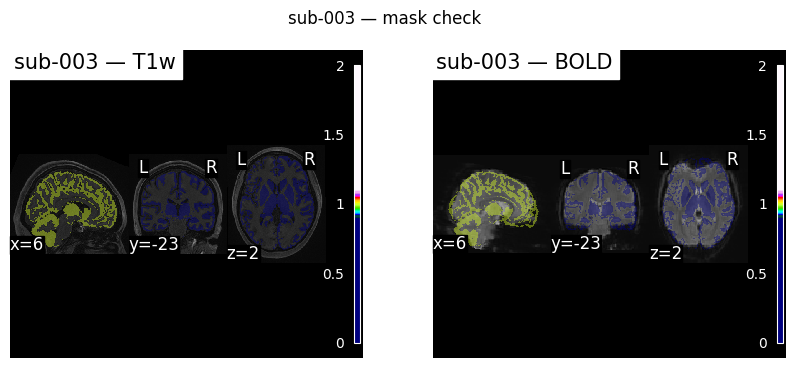

In [7]:
# STEP 3 — CHECK MASK VISUALLY

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'{sub} — mask check', fontsize=12)
 
anat_img    = nib.load(anat_path)
bold_4d     = nib.load(bold_path)
boldref_img = bold_4d.slicer[..., 0]
 
plotting.plot_roi(mask, bg_img=anat_img,    alpha=0.4, display_mode='ortho',
                  draw_cross=False, axes=axes[0], title=f'{sub} — T1w',  figure=fig)
plotting.plot_roi(mask, bg_img=boldref_img, alpha=0.4, display_mode='ortho',
                  draw_cross=False, axes=axes[1], title=f'{sub} — BOLD', figure=fig)
plt.show()

  Mask shape: (78, 93, 65)
  Voxels above threshold: 56497


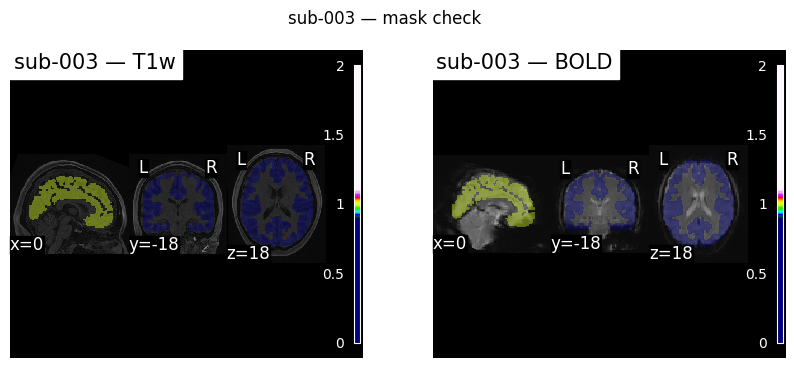

In [8]:
#check other mask
second_mask_path = '/jukebox/PNI-classes/students/NEU502/2026-NEU502B/binary_shaef.nii'

threshold = 0.4
mask_img_2  = nib.load(second_mask_path)
mask_sec      = nib.Nifti1Image(
    (mask_img_2.get_fdata() > threshold).astype(np.uint8),
    mask_img_2.affine,
    mask_img_2.header,
)
print(f'  Mask shape: {mask_sec.shape}')
print(f'  Voxels above threshold: {(mask_img_2.get_fdata() > threshold).sum()}')
 
# CHECK MASK VISUALLY

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'{sub} — mask check', fontsize=12)
 
anat_img    = nib.load(anat_path)
bold_4d     = nib.load(bold_path)
boldref_img = bold_4d.slicer[..., 0]
 
plotting.plot_roi(mask_sec, bg_img=anat_img,    alpha=0.4, display_mode='ortho',
                  draw_cross=False, axes=axes[0], title=f'{sub} — T1w',  figure=fig)
plotting.plot_roi(mask_sec, bg_img=boldref_img, alpha=0.4, display_mode='ortho',
                  draw_cross=False, axes=axes[1], title=f'{sub} — BOLD', figure=fig)
plt.show()

In [9]:
#STEP 4 Load bold + confounds

full_data = [nib.load(bold_path)]
n_frames  = full_data[0].shape[-1]
print(f'  BOLD shape:  {full_data[0].shape}')
print(f'  n_frames:    {n_frames}')
 
# Resample mask to BOLD space
mask = nl.image.resample_to_img(mask_sec, full_data[0], interpolation='nearest')
 
strategy      = ['motion', 'wm_csf', 'global_signal', 'compcor', 'scrub', 'high_pass']
confounds_all = [
    nl.interfaces.fmriprep.load_confounds(
        bold_path,
        strategy     = strategy,
        fd_threshold = 0.5,
        n_compcor    = 5,
        motion       = 'basic',
        demean       = False,
    )
]
print(f'  Confounds shape: {confounds_all[0][0].shape}')
 
sm_list = [x[1] for x in confounds_all]
sm_list = [np.arange(n_frames) if x is None else x for x in sm_list]
print(f'  Sample mask frames kept: {len(sm_list[0])} / {n_frames}')
 

  BOLD shape:  (78, 93, 78, 304)
  n_frames:    304
  Confounds shape: (304, 22)
  Sample mask frames kept: 240 / 304



── Building design matrix ───────────────────────────
  Design matrix shape: (304, 29)
  Columns: ['deterministic_easy', 'deterministic_hard', 'deterministic_medium', 'probabilistic_easy', 'probabilistic_hard', 'probabilistic_medium', 'a_comp_cor_112', 'a_comp_cor_113', 'a_comp_cor_114', 'a_comp_cor_115', 'a_comp_cor_116', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'csf', 'global_signal', 'rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter', 'constant']


/tmp/ipykernel_4177216/2261133964.py:8: UserWarning: The following unexpected columns in events data will be ignored: rt, difficulty, choice, ev_diff, value_difference, ratio
  matrix = make_first_level_design_matrix(
/tmp/ipykernel_4177216/2261133964.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


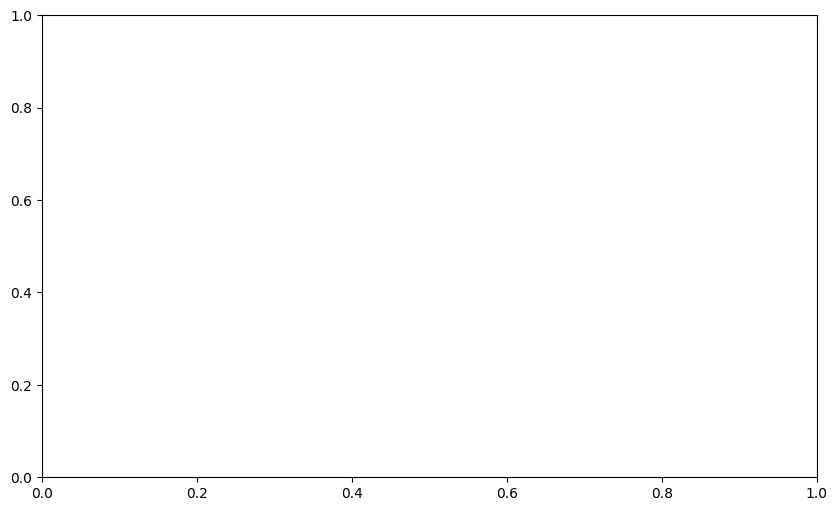

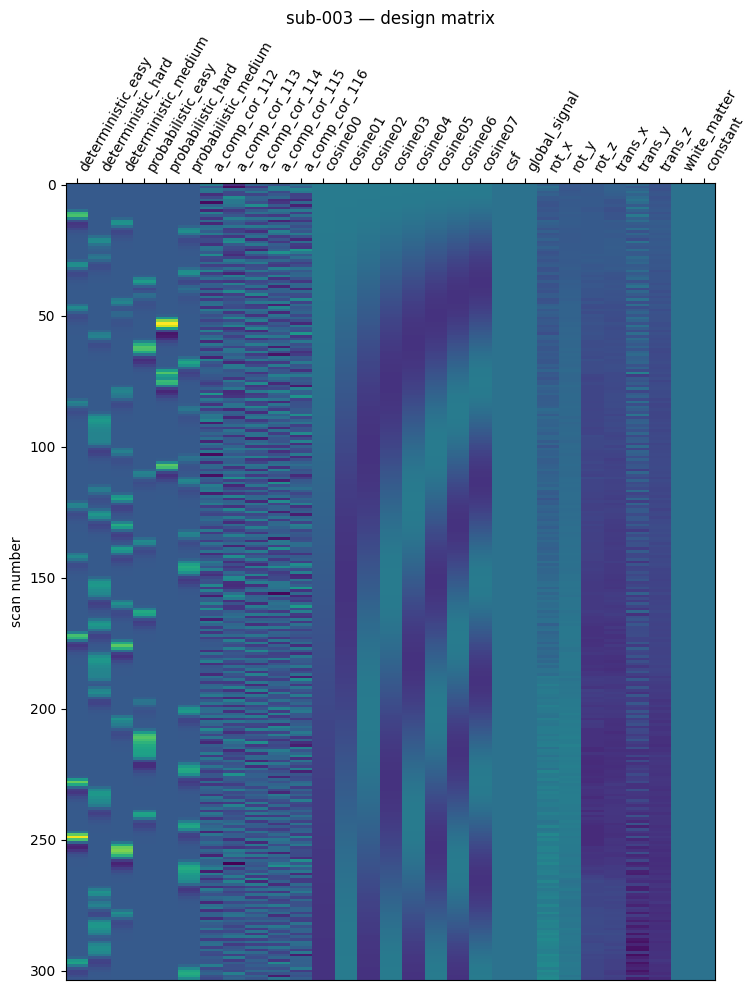

In [10]:
# STEP 5 — DESIGN MATRIX

print('\n── Building design matrix ───────────────────────────')
TR_array        = np.array([x * 2 for x in np.arange(n_frames)])
design_matrices = []
 
for e, c in zip([events], confounds_all):
    matrix = make_first_level_design_matrix(
        TR_array,
        e,
        hrf_model   = 'glover',
        drift_model = None,
        add_regs    = c[0],
    )
    design_matrices.append(matrix)
 
print(f'  Design matrix shape: {design_matrices[0].shape}')
print(f'  Columns: {design_matrices[0].columns.tolist()}')
 
# Plot design matrix
fig, ax = plt.subplots(figsize=(10, 6))
plotting.plot_design_matrix(design_matrices[0], output_file=None)
plt.title(f'{sub} — design matrix')
plt.tight_layout()
plt.show()

In [11]:
#STEP 6 FIT GLM
print('\n── Fitting GLM')

model = nl.glm.first_level.FirstLevelModel(
    t_r             = 2,
    hrf_model       = 'glover',
    mask_img        = mask,
    smoothing_fwhm  = 4,
    standardize     = 'zscore_sample',
    signal_scaling  = False,
    drift_model     = None,
    minimize_memory = False,
)

fitted_model = model.fit(
    full_data,
    design_matrices = design_matrices,
    sample_masks    = sm_list,
)
print('  Model fit complete')


── Fitting GLM


/tmp/ipykernel_4177216/4080211242.py:15: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  fitted_model = model.fit(


  Model fit complete


In [12]:
# STEP 7: BETA WEIGHTS + CONTRASTS

def build_contrasts(dm_cols: list) -> dict:
   
    condition = set(dm_cols)

    
    choice_type = {
        'deterministic_medium',
        'deterministic_easy',
        'probabilistic_hard',
        'probabilistic_medium',
        'probabilistic_easy',
    }
    missing = choice_type - condition
    if missing:
        raise ValueError(
            f'Design matrix is missing expected regressors: {missing}\n'
            f'  Found: {sorted(condition)}'
        )

    # Check if this subject has deterministic_hard (subjects 2 & 3 only)
    has_det_hard = "deterministic_hard" in condition

    print(f'  Regressors found: {sorted(choice_type & condition)}')
    print(f'  deterministic_hard present: {has_det_hard}')

    # ── Choice: deterministic > probabilistic ─────────────────────────────────
    # Sub-001 (5 regressors): det side = 2 conditions → weight 1/2 each
    # Sub-002/003 (6 regressors): det side = 3 conditions → weight 1/3 each
    if has_det_hard:
        det_avg  = '1/3 * deterministic_hard + 1/3 * deterministic_medium + 1/3 * deterministic_easy'
        prob_avg = "1/3 * probabilistic_hard + 1/3 * probabilistic_medium + 1/3 * probabilistic_easy"
    else:
        det_avg  = '1/2 * deterministic_medium + 1/2 * deterministic_easy'
        prob_avg = '1/3 * probabilistic_hard + 1/3 * probabilistic_medium + 1/3 * probabilistic_easy'

    # Difficulty: hard > easy 
    # hard side: only probabilistic_hard exists for sub-001
    # easy side: deterministic_easy + probabilistic_easy → weight 1/2 each
    # Weights match original: 1/2 * prob_hard - 1/2 * det_easy - 1/2 * prob_easy
    if has_det_hard:
        hard_contrast = (
            '1/2 * deterministic_hard + 1/2 * probabilistic_hard'
            ' - 1/2 * deterministic_easy - 1/2 * probabilistic_easy'
        )
        easy_contrast = (
            '1/2 * deterministic_easy + 1/2 * probabilistic_easy'
            ' - 1/2 * deterministic_hard - 1/2 * probabilistic_hard'
        )
    else:
        hard_contrast = (
            '1/2 * probabilistic_hard'
            ' - 1/2 * deterministic_easy - 1/2 * probabilistic_easy'
        )
        easy_contrast = (
            '1/2 * deterministic_easy + 1/2 * probabilistic_easy'
            '- 1/2 * probabilistic_hard'
        )

    # ── Interaction: does difficulty modulate det vs prob differently? ────────
    # (det_hard - det_easy) - (prob_hard - prob_easy)
    interaction = (
        'deterministic_hard - deterministic_easy'
         '- probabilistic_hard + probabilistic_easy'
    )

    # ── Task vs baseline: equal weight across all present conditions ──────────
    conditions_present = sorted(choice_type & condition |
                                ({'deterministic_hard'} if has_det_hard else set()))
    n = len(conditions_present)
    task_vs_baseline = " + ".join(f"1/{n} * {c}" for c in conditions_present)

    contrasts = {
        # Choice
        'det_vs_prob':         f'{det_avg} - {prob_avg}',
        'prob_vs_det':         f'{prob_avg} - {det_avg}',

        # Difficulty
        'hard_vs_easy':        hard_contrast,
        'easy_vs_hard':        easy_contrast,

        # Interaction
        'choice_x_difficulty': interaction,

        # Individual conditions
        'det_medium':          'deterministic_medium',
        'det_easy':            'deterministic_easy',
        'prob_hard':           'probabilistic_hard',
        'prob_medium':         'probabilistic_medium',
        'prob_easy':           'probabilistic_easy',

        # Task vs baseline
        'task_vs_baseline':    task_vs_baseline,
    }

    # Add det_hard only if present
    if has_det_hard:
        contrasts['det_hard'] = "deterministic_hard"

    return contrasts


#Run contrasts

print('\n── Design matrix columns (confirm regressor names) ──')
dm_cols = design_matrices[0].columns.tolist()
print(f'  {dm_cols}')

contrasts = build_contrasts(dm_cols)

for name, formula in contrasts.items():
    beta = fitted_model.compute_contrast(formula, output_type='effect_size')
    z    = fitted_model.compute_contrast(formula, output_type='z_score')
    print(f'  {name}:')


── Design matrix columns (confirm regressor names) ──
  ['deterministic_easy', 'deterministic_hard', 'deterministic_medium', 'probabilistic_easy', 'probabilistic_hard', 'probabilistic_medium', 'a_comp_cor_112', 'a_comp_cor_113', 'a_comp_cor_114', 'a_comp_cor_115', 'a_comp_cor_116', 'cosine00', 'cosine01', 'cosine02', 'cosine03', 'cosine04', 'cosine05', 'cosine06', 'cosine07', 'csf', 'global_signal', 'rot_x', 'rot_y', 'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter', 'constant']
  Regressors found: ['deterministic_easy', 'deterministic_medium', 'probabilistic_easy', 'probabilistic_hard', 'probabilistic_medium']
  deterministic_hard present: True
  det_vs_prob:
  prob_vs_det:
  hard_vs_easy:
  easy_vs_hard:
  choice_x_difficulty:
  det_medium:
  det_easy:
  prob_hard:
  prob_medium:
  prob_easy:
  task_vs_baseline:
  det_hard:


In [ ]:
# STEP 8A: SAVE BETA AND Z-SCORE MAPS-saves all 22 files for individual conditions
os.makedirs(results_dir, exist_ok=True)
date_time = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

def save_map(img, label):
    path = os.path.join(results_dir, f'{sub}_{label}_{date_time}.nii.gz')
    img.to_filename(path)
    print(f'  Saved → {path}')
    return path

print('\n── Saving beta and z-score maps ──')

contrasts = build_contrasts(dm_cols)

for name, formula in contrasts.items():
    beta = fitted_model.compute_contrast(formula, output_type='effect_size')
    z    = fitted_model.compute_contrast(formula, output_type='z_score')
    save_map(beta, f'beta-{name}')
    save_map(z,    f'z-{name}')
    print(f'  {name}: ✓')

print(f'\n── All maps saved to {results_dir}')

In [13]:
#STEP 8B- Combines files to only 9 files for GLM group analysis only

os.makedirs(results_dir, exist_ok=True)
date_time = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

def save_map(img, label):
    path = os.path.join(results_dir, f'{sub}_{label}_{date_time}.nii.gz')
    img.to_filename(path)
    print(f'  Saved → {path}')
    return path

# Only save the key contrasts, not individual condition betas
KEY_CONTRASTS = {
    'det_vs_prob',
    'prob_vs_det', 
    'hard_vs_easy',
    'easy_vs_hard',
    'choice_x_difficulty',
    'task_vs_baseline',
}

for name, formula in contrasts.items():
    if name not in KEY_CONTRASTS:
        continue
    beta = fitted_model.compute_contrast(formula, output_type='effect_size')
    save_map(beta, f'beta-{name}')

# Z-scores only for primary contrasts
for name in ['det_vs_prob', 'hard_vs_easy', 'choice_x_difficulty']:
    z = fitted_model.compute_contrast(contrasts[name], output_type='z_score')
    save_map(z, f'z-{name}')

  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-det_vs_prob_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-prob_vs_det_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-hard_vs_easy_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-easy_vs_hard_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-choice_x_difficulty_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_beta-task_vs_baseline_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_z-det_vs_prob_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb3/fmri_project/updated_first_level_GLM/sub-003/sub-003_z-hard_vs_easy_2026-04-10_21-39-37.nii.gz
  Saved → /scratch/snb

In [ ]:
#insert this line above to just save betas
#for name, formula in contrasts.items():
    #beta = fitted_model.compute_contrast(formula, output_type='effect_size')
    #save_map(beta, f'beta-{name}')